# Electronic Parts Country of Origin Prediction

Simple demo using BGE-Large embeddings via vLLM and KNN classification.

## 1. Setup and Configuration

In [24]:
!pip  install -q --upgrade pip
!pip  install -q "model-registry==0.2.15" "onnx==1.15.0" "skl2onnx==1.16.0" "onnxruntime==1.16.0" "seaborn" "openai"

In [25]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import sys
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('../utils/')
from vllm_client import create_vllm_client, get_embeddings

In [3]:
# Configuration - your vLLM details are set via environment variables
# These are automatically configured by the workbench deployment

EMBEDDING_MODEL_ENDPOINT = os.getenv('EMBEDDING_MODEL_ENDPOINT')
EMBEDDING_MODEL_NAME = os.getenv('EMBEDDING_MODEL_NAME')
EMBEDDING_MODEL_KEY = os.getenv('EMBEDDING_MODEL_KEY')

print(f"Endpoint: {EMBEDDING_MODEL_ENDPOINT}")
print(f"Model: {EMBEDDING_MODEL_NAME}")
print(f"API Key: {'[CONFIGURED]' if EMBEDDING_MODEL_KEY else '[MISSING - set in deployment]'}")

Endpoint: https://bge-large-arrow-chatbot.apps.cluster-bw7h2.bw7h2.sandbox5279.opentlc.com
Model: bge-large
API Key: [CONFIGURED]


## 2. Load Data

In [4]:
# Load the synthetic electronics data

df = pd.read_csv('../data/synthetic_electronics_parts_1k.csv')

df.head(10)

,Part_Description,Country_Of_Origin
0,"growing production wiring harness, volume prod...",Vietnam
1,A mobile-optimized processor for advanced appl...,South Korea
2,A high voltage connector (heavy duty) for high...,Germany
3,cable assembly (cost-efficient) with manual as...,Vietnam
4,Manufactured for high-quality needs: power mod...,Germany
5,sensor (industrial) (precision-engineered) wit...,Germany
6,A component-level standard logic IC for discre...,Malaysia
7,A space-grade microcontroller for aerospace ap...,USA
8,"miniature crystal oscillator, high-frequency.",Japan
9,wiring harness (growing production) with manua...,Vietnam


## 3. Connect to vLLM and Generate Embeddings

In [5]:
# Create vLLM client
client = create_vllm_client(EMBEDDING_MODEL_ENDPOINT, EMBEDDING_MODEL_NAME, EMBEDDING_MODEL_KEY)

In [6]:
# Generate embeddings for part descriptions
descriptions = df['Part_Description'].tolist()
print(f"🔄 Generating embeddings for {len(descriptions)} descriptions...")

embeddings = get_embeddings(client, descriptions, EMBEDDING_MODEL_NAME)

if embeddings:
    X = np.array(embeddings)
    print(f"✅ Generated embeddings with shape: {X.shape}")
    print(f"   - Embedding dimension: {X.shape[1]}")
else:
    print("❌ Failed to generate embeddings")
    print("Check your vLLM endpoint and API key configuration")

🔄 Generating embeddings for 1000 descriptions...
✅ Generated embeddings with shape: (1000, 1024)
   - Embedding dimension: 1024


## 4. Train KNN Classifier

In [7]:
# Prepare labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Country_Of_Origin'])
class_names = label_encoder.classes_

print(f"📊 Dataset info:")
print(f"   - Total samples: {len(X)}")
print(f"   - Number of countries: {len(class_names)}")
print(f"   - Countries: {list(class_names)}")

📊 Dataset info:
   - Total samples: 1000
   - Number of countries: 8
   - Countries: ['China', 'Germany', 'Japan', 'Malaysia', 'South Korea', 'Taiwan', 'USA', 'Vietnam']


In [8]:
# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Split data: {len(X_train)} train, {len(X_test)} test")


Split data: 800 train, 200 test


In [9]:
import joblib


In [10]:
# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
print(f"🤖 Training KNN classifier")
knn.fit(X_train, y_train)
print("✅ KNN training complete")

🤖 Training KNN classifier
✅ KNN training complete


In [11]:
from model_registry import ModelRegistry
from model_registry.utils import S3Params
from model_registry.exceptions import StoreError

## 5. Evaluate Model

In [12]:
# Make predictions
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Model Performance:")
print(f"   - Accuracy: {accuracy:.1%}")

🎯 Model Performance:
   - Accuracy: 94.0%


In [13]:
# Show detailed results
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


📊 Detailed Classification Report:
              precision    recall  f1-score   support

       China       1.00      0.83      0.91        24
     Germany       0.91      1.00      0.95        29
       Japan       1.00      1.00      1.00        26
    Malaysia       0.82      1.00      0.90        23
 South Korea       1.00      1.00      1.00        28
      Taiwan       0.88      0.96      0.92        23
         USA       0.94      0.70      0.80        23
     Vietnam       1.00      1.00      1.00        24

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.95      0.94      0.94       200



## 6. Visualize Results

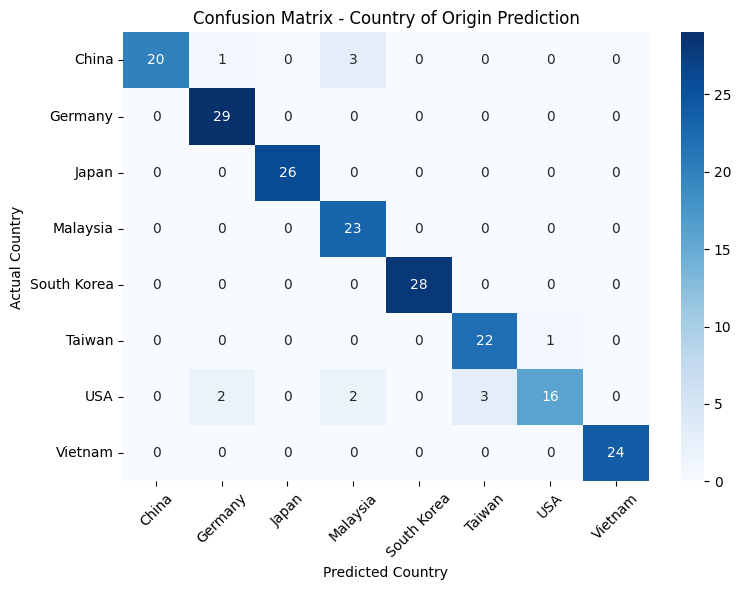

In [14]:
# Create confusion matrix
if len(class_names) > 1:
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Country of Origin Prediction')
    plt.xlabel('Predicted Country')
    plt.ylabel('Actual Country')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping confusion matrix (only one class)")

In [15]:
# Show sample predictions
print("\n🔍 Sample Predictions:")
print("=" * 80)

for i in range(min(len(X_test), 5)):
    desc = descriptions[i] if i < len(descriptions) else "Sample description"
    actual = class_names[y_test[i]]
    predicted = class_names[y_pred[i]]
    
    print(f"\nSample {i+1}:")
    print(f"Description: {desc[:100]}{'...' if len(desc) > 100 else ''}")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")
    print(f"Result: {'✅ Correct' if actual == predicted else '❌ Incorrect'}")


🔍 Sample Predictions:

Sample 1:
Description: growing production wiring harness, volume production.
Actual: South Korea
Predicted: South Korea
Result: ✅ Correct

Sample 2:
Description: A mobile-optimized processor for advanced applications.
Actual: Japan
Predicted: Japan
Result: ✅ Correct

Sample 3:
Description: A high voltage connector (heavy duty) for high-quality applications.USB Type-C high-density.
Actual: USA
Predicted: Germany
Result: ❌ Incorrect

Sample 4:
Description: cable assembly (cost-efficient) with manual assembly features.
Actual: China
Predicted: Germany
Result: ❌ Incorrect

Sample 5:
Description: Manufactured for high-quality needs: power module with harsh environment.
Actual: Taiwan
Predicted: Taiwan
Result: ✅ Correct


## 7. Test with New Examples

In [16]:
# Test with new part descriptions
test_descriptions = [
    "high-frequency RF transistor for mobile communication systems",
    "robust power MOSFET for electric vehicle inverters",
    "miniature MEMS accelerometer for wearable fitness trackers",
    "radiation-hardened FPGA for aerospace applications",
    "multi-layer ceramic inductor for high-efficiency DC-DC converters",
    "ultra-low-power Bluetooth SoC for IoT smart home devices",
    "thermally stable voltage regulator for telecom base stations",
    "automated LiDAR module for autonomous delivery drones",
    "waterproof piezoelectric buzzer for marine instrumentation",
    "energy-harvesting rectifier circuit for remote sensors"
]

print("🧪 Testing with new examples:")
print("=" * 50)

# Generate embeddings for test descriptions
test_embeddings = get_embeddings(client, test_descriptions, EMBEDDING_MODEL_NAME)

if test_embeddings:
    test_X = np.array(test_embeddings)
    test_predictions = knn.predict(test_X)
    test_probabilities = knn.predict_proba(test_X)
    
    for i, desc in enumerate(test_descriptions):
        predicted_country = class_names[test_predictions[i]]
        confidence = test_probabilities[i].max()
        
        print(f"\nTest {i+1}: {desc}")
        print(f"Predicted Country: {predicted_country}")
        print(f"Confidence: {confidence:.2f}")
else:
    print("❌ Failed to generate embeddings for test examples")

🧪 Testing with new examples:

Test 1: high-frequency RF transistor for mobile communication systems
Predicted Country: USA
Confidence: 0.67

Test 2: robust power MOSFET for electric vehicle inverters
Predicted Country: South Korea
Confidence: 0.67

Test 3: miniature MEMS accelerometer for wearable fitness trackers
Predicted Country: Germany
Confidence: 0.67

Test 4: radiation-hardened FPGA for aerospace applications
Predicted Country: USA
Confidence: 1.00

Test 5: multi-layer ceramic inductor for high-efficiency DC-DC converters
Predicted Country: Japan
Confidence: 1.00

Test 6: ultra-low-power Bluetooth SoC for IoT smart home devices
Predicted Country: Taiwan
Confidence: 0.67

Test 7: thermally stable voltage regulator for telecom base stations
Predicted Country: Taiwan
Confidence: 1.00

Test 8: automated LiDAR module for autonomous delivery drones
Predicted Country: Japan
Confidence: 1.00

Test 9: waterproof piezoelectric buzzer for marine instrumentation
Predicted Country: Germany
C

## 6. Save Model

In [21]:
# Create a directory to save the model
model_dir = '../models/coo-classifier/'
os.makedirs(model_dir, exist_ok=True)

encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
joblib.dump(label_encoder, encoder_path)
print(f"Label encoder saved to: {encoder_path}")

Label encoder saved to: ../models/coo-classifier/label_encoder.pkl


In [22]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Define input shape (1024 is your embedding dimension)
initial_type = [('float_input', FloatTensorType([None, 1024]))]

# Convert to ONNX
onnx_model = convert_sklearn(knn, initial_types=initial_type)

# Save ONNX model
onnx_path = os.path.join(model_dir, 'model.onnx')
with open(onnx_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f"✅ ONNX model saved to: {onnx_path}")

✅ ONNX model saved to: ../models/coo-classifier/model.onnx


## Summary

🎉 **Demo Complete!**

This notebook demonstrates:
- ✅ BGE-Large embeddings via vLLM API
- ✅ KNN classification for country prediction
- ✅ Model evaluation and visualization
- ✅ Real-time inference with new examples
- ✅ Convert model to ONNX and save

The model uses semantic embeddings from transformer models to understand the relationship between part descriptions and their likely countries of origin.